# Analysis of Residual Stream Activation Vectors (Raw + Deconfounded)

**Input files**:
- `INPUT_FILE` — a single `.pt` reasoning-vectors file produced by `run_fw_pass.py --type reasoning` with an additional deconfounding of the reasoning vectors with the pirncipal components of a chosen baseline dataset. Each layer contains:
  - `mean_correct_token`: global average of every correct reasoning token `[d_model]`
  - `mean_incorrect_token`: global average of every incorrect reasoning token `[d_model]`
  - `reasoning_direction_token`: `mean_correct_token - mean_incorrect_token` `[d_model]`
  - `per_sample_means`: per-sample average activation `[N_samples, d_model]`
  - `mean_correct_samples`: mean activation of perfectly-correct samples `[d_model]`
  - `mean_incorrect_samples`: mean activation of flawed samples `[d_model]`
  - `reasoning_direction_sample`: `mean_correct_samples - mean_incorrect_samples` `[d_model]`
  - `mean_correct_step`:          mean_correct_step,
  - `mean_incorrect_step`:        mean_incorrect_step,
  - `reasoning_direction_step`:   mean_correct_step - mean_incorrect_step,
    
          

- On the first run, do not have yet cleaned versions: 
  - `reasoning_direction_token_cleaned`: `reasoning_direction_token` deconfounded with chosen baseline
  - `reasoning_direction_sample_cleaned`: `reasoning_direction_sample` deconfounded with chosen baseline

**Analysis done**:
- Token and sample level (cosine) similarity of activations for reasoning (ProcessBench) dataset
- Unsupervised clustering method (Principal component analysis) for per-sample activation means
- Overlap of reasoning vectors with baseline principal components

## Set-up

In [16]:
!pip install matplotlib seaborn scikit-learn numpy torch --quiet

In [17]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns
import math
import copy
from sklearn.decomposition import PCA
from pathlib import Path

sns.set_theme(style="whitegrid")

In [18]:
# ── File paths ────────────────────────────────────────────────────────────────
# RAW AND DE-CONFOUNDED REASONING VECTORS FOR DIFF BASELINE DATASETS
INPUT_FILE_RAW_VECTORS = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_Qwen3-8B_processbench_with_steps_avg.pt"
INPUT_FILE_RAW_VECTORS_2= "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_cleaned_fineweb.pt"


INPUT_FILE_CLEANED_VECTORS_FINEWEB = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_cleaned_fineweb.pt"
INPUT_FILE_CLEANED_VECTORS_DEEPMIND_MATH = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_cleaned_deepmind_math.pt"
INPUT_FILE_CLEANED_VECTORS_JOINT_FINEWEB_DEEPMIND_MATH = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_cleaned_joint_fineweb_deepmind_math.pt"

# PCA COMPONENTS OF BASELINE DATASET
BASELINE_PCA_FILE_FINEWEB = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/fineweb_pca_components.pt"     
BASELINE_PCA_FILE_DEEPMIND_MATH = "/home/ines/Reasoning-activations/baseline_vectors/Qwen3-8B/deepmind_math_pca_components_20000samples.pt"
BASELINE_PCA_FILE_JOINT_FINEWEB_DEEPMIND_MATH = "/home/ines/Reasoning-activations/baseline_vectors/Qwen3-8B/joint_pca_fineweb_deepmind_40000samples.pt"


INPUT_FILE_CLEANED_VECTORS = INPUT_FILE_CLEANED_VECTORS_JOINT_FINEWEB_DEEPMIND_MATH

BASELINE_PCA = BASELINE_PCA_FILE_FINEWEB

# the cleaned vectors baseline dataset must correspond with chosen baseline_pca file!!!

# 1. Extract components using pathlib
# file_path = Path(INPUT_FILE_CLEANED_VECTORS)
file_path = Path(INPUT_FILE_RAW_VECTORS)
path_parts = file_path.parts

# Find the index of 'reasoning_vectors' to relative-reference the next folders
rv_idx = path_parts.index("reasoning_vectors")
model_name = path_parts[rv_idx + 1]
reasoning_dataset = path_parts[rv_idx + 2]

# Extract baseline_dataset by removing prefix and suffix from the filename
# baseline_dataset = file_path.stem.replace("reasoning_vectors_cleaned_", "")
# Map the selected BASELINE_PCA to the desired baseline_dataset string
pca_to_dataset_name = {
    BASELINE_PCA_FILE_FINEWEB: "fineweb",
    BASELINE_PCA_FILE_DEEPMIND_MATH: "deepmind_math",
    BASELINE_PCA_FILE_JOINT_FINEWEB_DEEPMIND_MATH: "joint_fineweb_deepmind_math"
}

# Extract baseline_dataset dynamically (falls back to "unknown_baseline" if not found in dict)
baseline_dataset = pca_to_dataset_name.get(BASELINE_PCA, "unknown_baseline")

# 2. Define output directory and ensure it exists
out_dir = Path(f"/home/ines/Reasoning-activations/results/01_reasoning_vector_analysis/{model_name}/{reasoning_dataset}")
out_dir.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = file_path.parent / f"reasoning_vectors_with_step_cleaned_{baseline_dataset}.pt"

# ─────────────────────────────────────────────────────────────────────────────

## Load input file

In [19]:
data = torch.load(INPUT_FILE_RAW_VECTORS, map_location="cpu")

meta   = data["metadata"]
layers = data["layers"]

# Sort layer names by their integer index (e.g. "blocks.18.hook_out" → 18)
sorted_layer_names = sorted(
    layers.keys(),
    key=lambda x: int(x.split(".")[1])
)

# Per-sample correctness mask
is_perfect_mask = meta["per_sample_is_fully_correct"]   # bool tensor [N_samples]
y_mask          = is_perfect_mask.numpy()

print(f"Model          : {meta.get('model', 'N/A')}")
print(f"Target layers  : {meta.get('target_layers', 'N/A')}")
print(f"Correct tokens : {meta.get('count_correct_tokens', 'N/A')}")
print(f"Incorrect tokens : {meta.get('count_incorrect_tokens', 'N/A')}")
print(f"Correct steps : {meta.get('count_correct_steps', 'N/A')}")
print(f"Incorrect steps : {meta.get('count_incorrect_steps', 'N/A')}")
print(f"Perfect samples: {is_perfect_mask.sum().item()}")
print(f"Flawed samples : {(~is_perfect_mask).sum().item()}")
print(f"Layers found   : {sorted_layer_names}")

Model          : Qwen/Qwen3-8B
Target layers  : [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
Correct tokens : 1212091
Incorrect tokens : 1085814
Correct steps : 14327
Incorrect steps : 2221
Perfect samples: 1179
Flawed samples : 2221
Layers found   : ['blocks.18.hook_out', 'blocks.19.hook_out', 'blocks.20.hook_out', 'blocks.21.hook_out', 'blocks.22.hook_out', 'blocks.23.hook_out', 'blocks.24.hook_out', 'blocks.25.hook_out', 'blocks.26.hook_out', 'blocks.27.hook_out', 'blocks.28.hook_out']


## Load baseline PCA components

In [20]:
baseline_pca = torch.load(BASELINE_PCA, map_location="cpu")
pca_by_layer = baseline_pca["layers"]   # keys are int layer indices
    
def get_baseline_components(layer_name: str):
    """
    Look up PCA components for a layer whose name is e.g. 'blocks.18.hook_out'.
    This unified version supports dictionaries with either string keys or integer keys.
    Returns a numpy array of shape [n_components, d_model].
    """
    # Option 1: The dictionary uses the exact string as the key
    if layer_name in pca_by_layer:
        return pca_by_layer[layer_name].to(torch.float32).numpy()
    
    # Option 2: The dictionary uses integer keys (fallback)
    try:
        layer_idx = int(layer_name.split(".")[1])
        return pca_by_layer[layer_idx].to(torch.float32).numpy()
    except (IndexError, ValueError) as e:
        raise KeyError(f"Could not find key '{layer_name}' or its integer index in pca_by_layer.") from e
    
def project_out_components(vec: torch.Tensor, components: np.ndarray) -> torch.Tensor:
    """
    Project out a set of (orthogonal, unit-norm) PCA components from a vector.
    Works for both 1-D vectors [d_model] and 2-D matrices [N, d_model].
    """
    x = vec.to(torch.float32).numpy().copy()
    original_shape = x.shape
    if x.ndim == 1:
        x = x.reshape(1, -1)
    for comp in components:                              # comp: [d_model]
        projection = x @ comp                           # [N]
        x -= projection[:, None] * comp[None, :]        # subtract component
    return torch.tensor(x.reshape(original_shape), dtype=vec.dtype)


print("Baseline PCA file loaded.")
print(f"Layers in baseline file: {list(pca_by_layer.keys())}")

Baseline PCA file loaded.
Layers in baseline file: ['blocks.18.hook_out', 'blocks.19.hook_out', 'blocks.20.hook_out', 'blocks.21.hook_out', 'blocks.22.hook_out', 'blocks.23.hook_out', 'blocks.24.hook_out', 'blocks.25.hook_out', 'blocks.26.hook_out', 'blocks.27.hook_out', 'blocks.28.hook_out']


In [21]:
# ── Diagnostic: what did per_step_key pick up? ────────────────────────────────
sample_ld = layers[sorted_layer_names[0]]

print("All keys in layer dict:")
for k in sorted(sample_ld.keys()):
    v = sample_ld[k]
    if isinstance(v, torch.Tensor):
        print(f"  {k:45s}  shape={str(list(v.shape)):20s}  dtype={v.dtype}")
    else:
        print(f"  {k:45s}  type={type(v).__name__}")

All keys in layer dict:
  mean_correct_samples                           shape=[4096]                dtype=torch.float32
  mean_correct_step                              shape=[4096]                dtype=torch.float32
  mean_correct_token                             shape=[4096]                dtype=torch.float32
  mean_incorrect_samples                         shape=[4096]                dtype=torch.float32
  mean_incorrect_step                            shape=[4096]                dtype=torch.float32
  mean_incorrect_token                           shape=[4096]                dtype=torch.float32
  per_sample_means                               shape=[3400, 4096]          dtype=torch.float32
  reasoning_direction_sample                     shape=[4096]                dtype=torch.float32
  reasoning_direction_step                       shape=[4096]                dtype=torch.float32
  reasoning_direction_token                      shape=[4096]                dtype=torch.float32


## Compute overlap of (original) reasoning vectors with the baseline subspace
Compute the percentage of the original reasoning direction vector's magnitude that is captured by (or "lies within") the Principal Component (PCA) subspace of the baseline dataset.


We subtract the projection of each steering vector onto the basline PC subspace. This removes variance that is shared with generic language processing, leaving a cleaner signal that is more specific to the *correctness* of mathematical reasoning.



=== Projecting out baseline PCA components ===
Layer blocks.18.hook_out  (4 components)  |  token: 7.464→6.202 (55.6%)  |  sample: 9.181→5.212 (82.3%)  |  step: 7.926→4.650 (81.0%)
Layer blocks.19.hook_out  (5 components)  |  token: 9.861→8.430 (51.9%)  |  sample: 10.265→6.513 (77.3%)  |  step: 8.979→5.748 (76.8%)
Layer blocks.20.hook_out  (7 components)  |  token: 10.101→8.843 (48.3%)  |  sample: 10.428→7.232 (72.0%)  |  step: 9.407→6.471 (72.6%)
Layer blocks.21.hook_out  (7 components)  |  token: 11.570→10.189 (47.4%)  |  sample: 11.679→8.064 (72.3%)  |  step: 10.877→7.663 (71.0%)
Layer blocks.22.hook_out  (8 components)  |  token: 13.485→11.290 (54.7%)  |  sample: 12.985→9.815 (65.5%)  |  step: 12.275→9.277 (65.5%)
Layer blocks.23.hook_out  (10 components)  |  token: 15.658→13.882 (46.3%)  |  sample: 14.261→12.084 (53.1%)  |  step: 13.547→11.535 (52.4%)
Layer blocks.24.hook_out  (13 components)  |  token: 17.626→15.592 (46.6%)  |  sample: 16.459→14.184 (50.7%)  |  step: 15.144→12.95

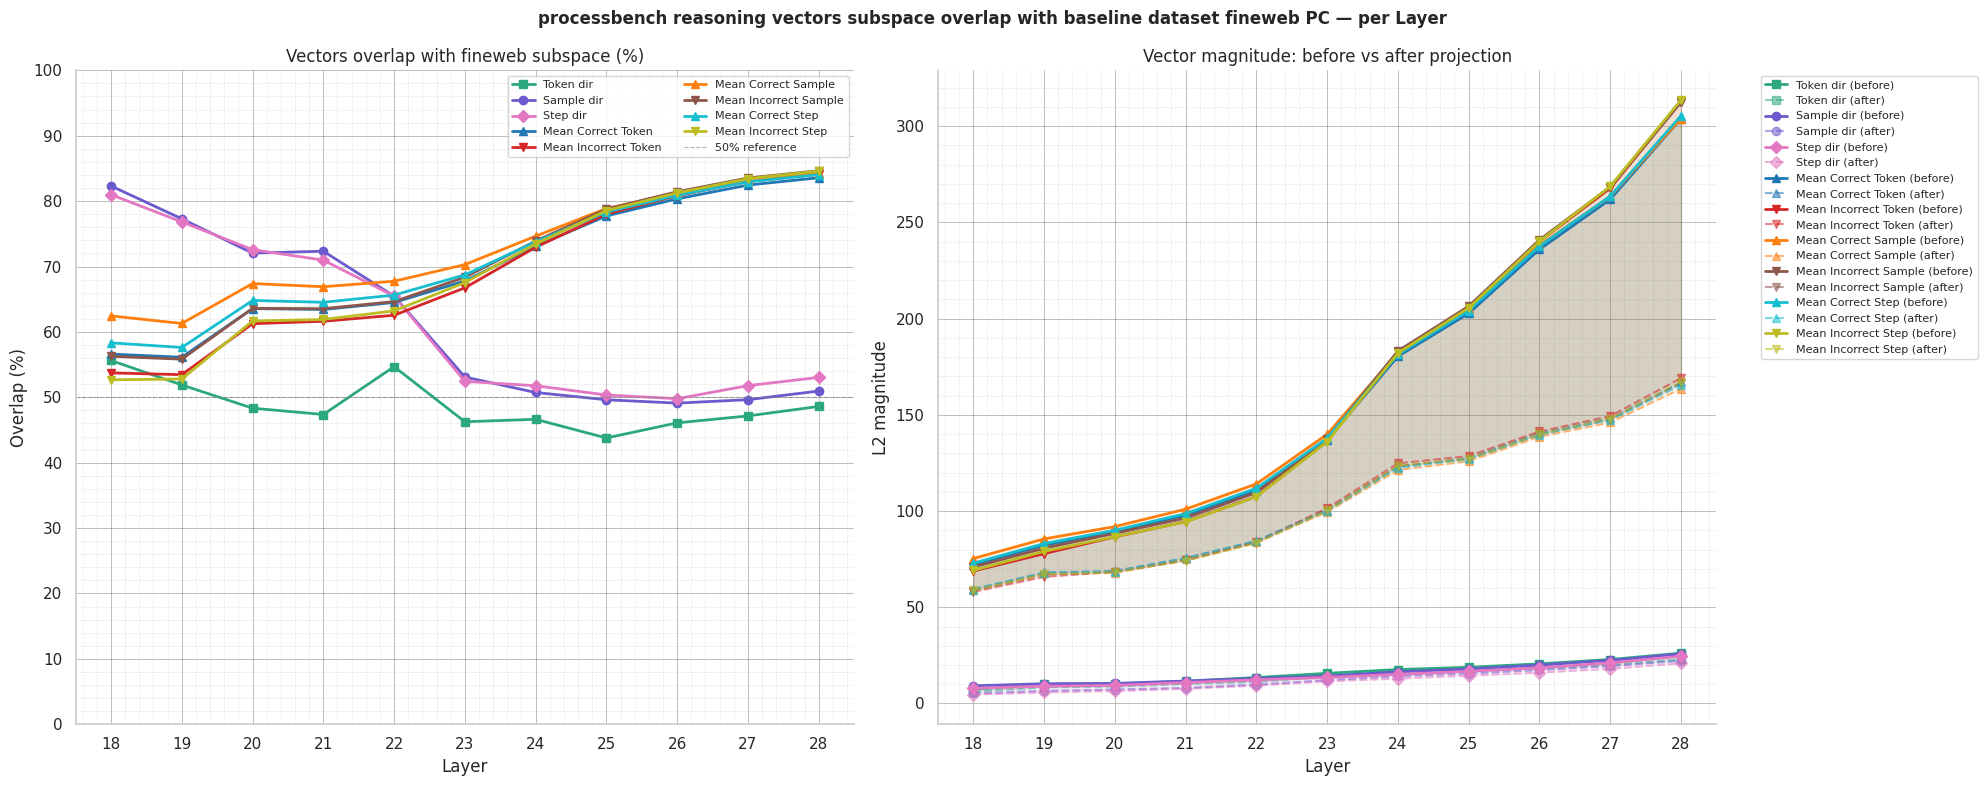

In [22]:
print("=== Projecting out baseline PCA components ===")

# 1. Setup mapping for all 9 target vectors we are analyzing
key_mapping = {
    "rd_token":  "reasoning_direction_token",
    "rd_sample": "reasoning_direction_sample",
    "rd_step":   "reasoning_direction_step",
    "mct":       "mean_correct_token",
    "mit":       "mean_incorrect_token",
    "mcs":       "mean_correct_samples",
    "mis":       "mean_incorrect_samples",
    "mc_step":   "mean_correct_step",
    "mi_step":   "mean_incorrect_step"
}
keys = list(key_mapping.keys())

# 2. RENAMED: Use `plot_metrics` so we don't overwrite the global PyTorch `data` variable!
plot_metrics = {
    "overlap_pct": {k: [] for k in keys},
    "mag_before":  {k: [] for k in keys},
    "mag_after":   {k: [] for k in keys}
}
valid_layer_indices = []

# Helper function to prevent redundant overlap calculation code
def get_overlap(vec, orig_mag, comps):
    vec_np = vec.to(torch.float32).numpy()
    dot_vals = torch.tensor(np.array([
        np.dot(vec_np / (orig_mag + 1e-12), c) for c in comps
    ]))
    return torch.sqrt((dot_vals**2).sum()).item()

for layer_name in sorted_layer_names:
    ld = layers[layer_name]

    try:
        components = get_baseline_components(layer_name)
    except KeyError as e:
        print(f"  WARNING: {e}. Skipping layer.")
        continue

    n_comp = components.shape[0]

    vecs = {}
    vecs_cleaned = {}

    # Extract baseline vectors and check/compute cleaned versions dynamically
    for k, full_name in key_mapping.items():
        vecs[k] = ld[full_name]
        
        cleaned_name = f"{full_name}_cleaned"
        if cleaned_name in ld:
            vecs_cleaned[k] = ld[cleaned_name]
        else:
            # Project out the components
            vecs_cleaned[k] = project_out_components(vecs[k], components)
            
            # FIXED: Save the computed cleaned vector back into `ld` (and thus `data`) in-place!
            ld[cleaned_name] = vecs_cleaned[k]

    log_strs = []
    # Compute everything in a simple loop over the 9 keys
    for k in keys:
        orig_mag = torch.norm(vecs[k]).item()
        clean_mag = torch.norm(vecs_cleaned[k]).item()
        overlap = get_overlap(vecs[k], orig_mag, components)
        
        plot_metrics["overlap_pct"][k].append(overlap * 100)
        plot_metrics["mag_before"][k].append(orig_mag)
        plot_metrics["mag_after"][k].append(clean_mag)
        
        # Keep the printed log concise by only formatting directions
        if k in ["rd_token", "rd_sample", "rd_step"]:
            name = k.replace("rd_", "")
            log_strs.append(f"{name}: {orig_mag:.3f}→{clean_mag:.3f} ({overlap*100:.1f}%)")

    valid_layer_indices.append(int(layer_name.split(".")[1]))

    print(f"Layer {layer_name}  ({n_comp} components)  |  " + "  |  ".join(log_strs))

print("\n=== Projection complete ===")

# ── Plot ──────────────────────────────────────────────────────────────────
# Extend styling definitions for the 9 different series
colors = {
    "rd_token":  "#2ca87f", # GREEN
    "rd_sample": "#6a5acd", # PURPLE
    "rd_step":   "#e377c2", # PINK
    "mct":       "#1f77b4", # BLUE
    "mit":       "#d62728", # RED
    "mcs":       "#ff7f0e", # ORANGE
    "mis":       "#8c564b", # BROWN
    "mc_step":   "#17becf", # CYAN
    "mi_step":   "#bcbd22"  # OLIVE
}

labels = {
    "rd_token":  "Token dir",
    "rd_sample": "Sample dir",
    "rd_step":   "Step dir",
    "mct":       "Mean Correct Token",
    "mit":       "Mean Incorrect Token",
    "mcs":       "Mean Correct Sample",
    "mis":       "Mean Incorrect Sample",
    "mc_step":   "Mean Correct Step",
    "mi_step":   "Mean Incorrect Step"
}

markers = {
    "rd_token":  "s",
    "rd_sample": "o",
    "rd_step":   "D",
    "mct":       "^",
    "mit":       "v",
    "mcs":       "^",
    "mis":       "v",
    "mc_step":   "^",
    "mi_step":   "v"
}

# Increased width slightly to accommodate the larger outer legend
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f"{reasoning_dataset} reasoning vectors subspace overlap with baseline dataset {baseline_dataset} PC — per Layer", fontsize=12, fontweight="bold")

# Left: overlap %
for k in keys:
    ax1.plot(valid_layer_indices, plot_metrics["overlap_pct"][k], f"{markers[k]}-", color=colors[k], lw=2, label=labels[k])
    
ax1.axhline(50, color="gray", lw=0.8, ls="--", alpha=0.6, label="50% reference")
ax1.set_title(f"Vectors overlap with {baseline_dataset} subspace (%)")
ax1.set_ylabel("Overlap (%)")
ax1.set_ylim(0, 100)
ax1.set_yticks(range(0, 101, 10)) 
ax1.legend(fontsize=8, ncol=2)

# Right: magnitude before vs after
for k in keys:
    ax2.plot(valid_layer_indices, plot_metrics["mag_before"][k], f"{markers[k]}-",  color=colors[k], lw=2, label=f"{labels[k]} (before)")
    ax2.plot(valid_layer_indices, plot_metrics["mag_after"][k],  f"{markers[k]}--", color=colors[k], lw=1.5, alpha=0.55, label=f"{labels[k]} (after)")
    ax2.fill_between(valid_layer_indices, plot_metrics["mag_after"][k], plot_metrics["mag_before"][k], color=colors[k], alpha=0.07)

ax2.set_title("Vector magnitude: before vs after projection")
ax2.set_ylabel("L2 magnitude")
# Moved legend outside bounds since 18 lines will clutter the chart heavily
ax2.legend(fontsize=8, ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left')

for ax in (ax1, ax2):
    ax.set_xlabel("Layer")
    ax.set_xticks(valid_layer_indices)
    
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.6, color="gray", linestyle="-", lw=0.6)
    ax.grid(True, which="minor", alpha=0.2, color="gray", linestyle="--", lw=0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(out_dir / f"overlap_projection_{baseline_dataset}_extended.png", dpi=150, bbox_inches="tight")
plt.show()

Correct samples used per split-half: ~589 / 1179


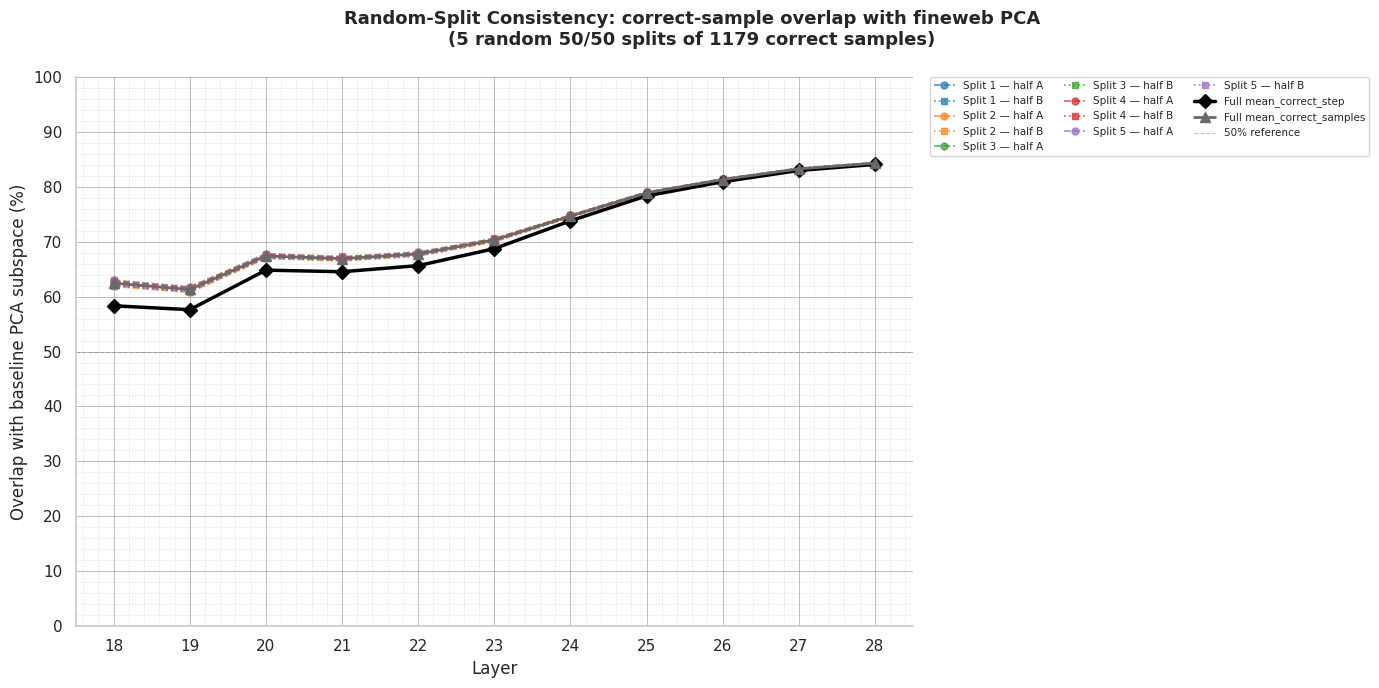


Per-layer mean ± std of split-half overlaps (%) across 10 halves:
  Layer 18: 62.4 ± 0.4%  (mc_step: 58.3%,  mc_sample: 62.4%)
  Layer 19: 61.3 ± 0.4%  (mc_step: 57.6%,  mc_sample: 61.3%)
  Layer 20: 67.4 ± 0.3%  (mc_step: 64.8%,  mc_sample: 67.4%)
  Layer 21: 66.9 ± 0.3%  (mc_step: 64.5%,  mc_sample: 66.9%)
  Layer 22: 67.7 ± 0.3%  (mc_step: 65.6%,  mc_sample: 67.8%)
  Layer 23: 70.3 ± 0.2%  (mc_step: 68.7%,  mc_sample: 70.3%)
  Layer 24: 74.6 ± 0.1%  (mc_step: 73.8%,  mc_sample: 74.6%)
  Layer 25: 78.9 ± 0.1%  (mc_step: 78.3%,  mc_sample: 78.9%)
  Layer 26: 81.3 ± 0.1%  (mc_step: 80.9%,  mc_sample: 81.3%)
  Layer 27: 83.2 ± 0.1%  (mc_step: 83.0%,  mc_sample: 83.2%)
  Layer 28: 84.3 ± 0.1%  (mc_step: 84.1%,  mc_sample: 84.3%)


In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# Random-split consistency: Correct-sample means vs Baseline PCA
# ═══════════════════════════════════════════════════════════════════════════════
# No per-step activations are stored in the _avg.pt file, so we use
# per_sample_means[is_perfect_mask] — the per-sample mean activations for
# correct/perfect samples.  For each of 5 random 50/50 splits, compute
# the group mean and measure its overlap with the baseline PCA subspace.
# ═══════════════════════════════════════════════════════════════════════════════

N_SPLITS = 5
SEED_BASE = 42

split_overlaps = {s: {"A": [], "B": []} for s in range(N_SPLITS)}
original_overlap_mc_step = []
original_overlap_mc_sample = []
valid_layer_indices_split = []

for layer_name in sorted_layer_names:
    ld = layers[layer_name]

    try:
        components = get_baseline_components(layer_name)
    except KeyError:
        continue

    # ── Per-sample activations for correct samples ────────────────────────
    all_sample_acts = ld["per_sample_means"].to(torch.float32)   # [3400, 4096]
    correct_acts = all_sample_acts[is_perfect_mask]               # [~1178, 4096]
    N = correct_acts.shape[0]

    # ── Reference overlaps ────────────────────────────────────────────────
    mc_step_vec = ld["mean_correct_step"].to(torch.float32)
    mc_step_mag = torch.norm(mc_step_vec).item()
    original_overlap_mc_step.append(
        get_overlap(mc_step_vec, mc_step_mag, components) * 100
    )

    mc_samp_vec = ld["mean_correct_samples"].to(torch.float32)
    mc_samp_mag = torch.norm(mc_samp_vec).item()
    original_overlap_mc_sample.append(
        get_overlap(mc_samp_vec, mc_samp_mag, components) * 100
    )

    valid_layer_indices_split.append(int(layer_name.split(".")[1]))

    # ── Random 50/50 splits ───────────────────────────────────────────────
    for s in range(N_SPLITS):
        rng = np.random.RandomState(SEED_BASE + s)
        perm = rng.permutation(N)
        half = N // 2

        mean_A = correct_acts[perm[:half]].mean(dim=0)
        mean_B = correct_acts[perm[half:]].mean(dim=0)

        mag_A = torch.norm(mean_A).item()
        mag_B = torch.norm(mean_B).item()

        split_overlaps[s]["A"].append(get_overlap(mean_A, mag_A, components) * 100)
        split_overlaps[s]["B"].append(get_overlap(mean_B, mag_B, components) * 100)

print(f"Correct samples used per split-half: ~{N // 2} / {N}")

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap = plt.cm.tab10
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle(
    f"Random-Split Consistency: correct-sample overlap with {baseline_dataset} PCA\n"
    f"({N_SPLITS} random 50/50 splits of {N} correct samples)",
    fontsize=13, fontweight="bold"
)

for s in range(N_SPLITS):
    c = cmap(s)
    ax.plot(valid_layer_indices_split, split_overlaps[s]["A"],
            "o--", color=c, lw=1.3, alpha=0.7, markersize=5,
            label=f"Split {s+1} — half A")
    ax.plot(valid_layer_indices_split, split_overlaps[s]["B"],
            "s:",  color=c, lw=1.3, alpha=0.7, markersize=5,
            label=f"Split {s+1} — half B")

# Reference lines
ax.plot(valid_layer_indices_split, original_overlap_mc_step,
        "D-", color="black", lw=2.5, markersize=7, zorder=10,
        label="Full mean_correct_step")
ax.plot(valid_layer_indices_split, original_overlap_mc_sample,
        "^-", color="dimgray", lw=2, markersize=7, zorder=10,
        label="Full mean_correct_samples")

ax.axhline(50, color="gray", lw=0.8, ls="--", alpha=0.5, label="50% reference")
ax.set_xlabel("Layer")
ax.set_ylabel("Overlap with baseline PCA subspace (%)")
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.set_xticks(valid_layer_indices_split)

ax.legend(fontsize=7.5, ncol=3, loc="upper left",
          bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.minorticks_on()
ax.grid(True, which="major", alpha=0.6, color="gray", linestyle="-", lw=0.6)
ax.grid(True, which="minor", alpha=0.2, color="gray", linestyle="--", lw=0.5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(out_dir / f"random_split_overlap_correct_samples_{baseline_dataset}.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
all_halves = np.array(
    [split_overlaps[s][h] for s in range(N_SPLITS) for h in ("A", "B")]
)  # [10, n_layers]
print(f"\nPer-layer mean ± std of split-half overlaps (%) across {N_SPLITS*2} halves:")
for i, li in enumerate(valid_layer_indices_split):
    vals = all_halves[:, i]
    print(f"  Layer {li}: {vals.mean():.1f} ± {vals.std():.1f}%  "
          f"(mc_step: {original_overlap_mc_step[i]:.1f}%,  "
          f"mc_sample: {original_overlap_mc_sample[i]:.1f}%)")

Using per-step activation key: 'mean_correct_step'  (shape in first layer: torch.Size([4096]))


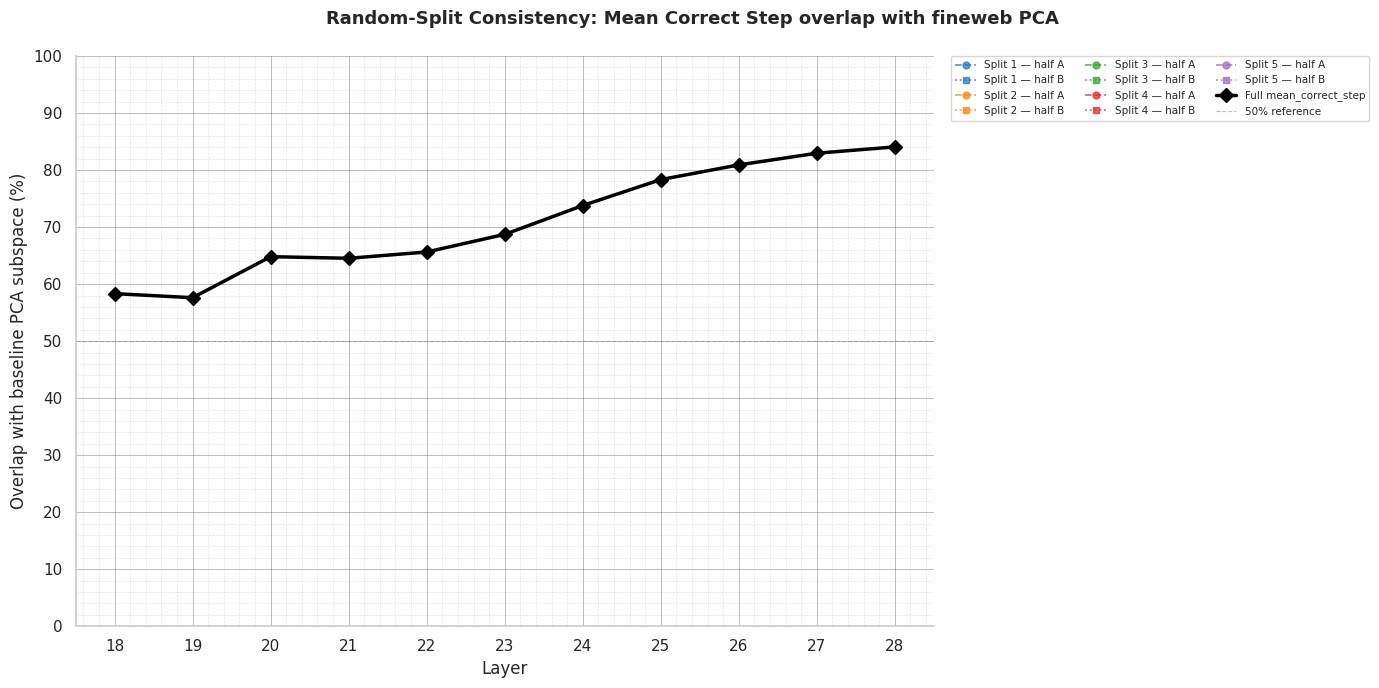


Per-layer mean ± std of split-half overlaps (%) across 10 halves:
  Layer 18: 200.0 ± 0.0%  (full mean: 58.3%)
  Layer 19: 223.6 ± 0.0%  (full mean: 57.6%)
  Layer 20: 264.6 ± 0.0%  (full mean: 64.8%)
  Layer 21: 264.6 ± 0.0%  (full mean: 64.5%)
  Layer 22: 282.8 ± 0.0%  (full mean: 65.6%)
  Layer 23: 316.2 ± 0.0%  (full mean: 68.7%)
  Layer 24: 360.6 ± 0.0%  (full mean: 73.8%)
  Layer 25: 400.0 ± 0.0%  (full mean: 78.3%)
  Layer 26: 435.9 ± 0.0%  (full mean: 80.9%)
  Layer 27: 458.3 ± 0.0%  (full mean: 83.0%)
  Layer 28: 479.6 ± 0.0%  (full mean: 84.1%)


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# Random-split consistency analysis: Mean Correct Step vs Baseline PCA
# ═══════════════════════════════════════════════════════════════════════════════
# For each of 5 random 50/50 splits of the individual correct-step activations,
# compute the mean of each half and measure its overlap with the baseline PCA
# subspace.  Plot all split-halves alongside the original mean_correct_step.
# ═══════════════════════════════════════════════════════════════════════════════

import torch, numpy as np, matplotlib.pyplot as plt

N_SPLITS = 5
SEED_BASE = 42

# ── Step 1: Discover the per-step activation key ─────────────────────────────
sample_ld = layers[sorted_layer_names[0]]
all_keys = list(sample_ld.keys())


per_step_key = "mean_correct_step"
print(f"Using per-step activation key: '{per_step_key}'  "
          f"(shape in first layer: {sample_ld[per_step_key].shape})")

# ── Step 2: Run the split analysis ───────────────────────────────────────────
if per_step_key is not None:

    # Storage: overlap_pct[split_idx][half] = list over layers
    split_overlaps = {
        s: {"A": [], "B": []} for s in range(N_SPLITS)
    }
    original_overlap = []   # the full mean_correct_step overlap (reference line)
    valid_layer_indices_split = []

    for layer_name in sorted_layer_names:
        ld = layers[layer_name]

        try:
            components = get_baseline_components(layer_name)
        except KeyError:
            continue

        acts = ld[per_step_key].to(torch.float32)          # [N_steps, d_model]
        N = acts.shape[0]

        # Original full-mean overlap (reference)
        full_mean = ld["mean_correct_step"].to(torch.float32)
        orig_mag = torch.norm(full_mean).item()
        orig_ovlp = get_overlap(full_mean, orig_mag, components) * 100
        original_overlap.append(orig_ovlp)

        valid_layer_indices_split.append(int(layer_name.split(".")[1]))

        # Random splits
        for s in range(N_SPLITS):
            rng = np.random.RandomState(SEED_BASE + s)
            perm = rng.permutation(N)
            half = N // 2
            idx_A, idx_B = perm[:half], perm[half:]

            mean_A = acts[idx_A].mean(dim=0)
            mean_B = acts[idx_B].mean(dim=0)

            mag_A = torch.norm(mean_A).item()
            mag_B = torch.norm(mean_B).item()

            split_overlaps[s]["A"].append(get_overlap(mean_A, mag_A, components) * 100)
            split_overlaps[s]["B"].append(get_overlap(mean_B, mag_B, components) * 100)

    # ── Step 3: Plot ──────────────────────────────────────────────────────────
    cmap = plt.cm.tab10
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.suptitle(
        f"Random-Split Consistency: Mean Correct Step overlap with {baseline_dataset} PCA",
        fontsize=13, fontweight="bold"
    )

    # Plot each split's two halves
    for s in range(N_SPLITS):
        c = cmap(s)
        ax.plot(valid_layer_indices_split, split_overlaps[s]["A"],
                "o--", color=c, lw=1.3, alpha=0.7, markersize=5,
                label=f"Split {s+1} — half A")
        ax.plot(valid_layer_indices_split, split_overlaps[s]["B"],
                "s:", color=c, lw=1.3, alpha=0.7, markersize=5,
                label=f"Split {s+1} — half B")

    # Reference: original full-data mean
    ax.plot(valid_layer_indices_split, original_overlap,
            "D-", color="black", lw=2.5, markersize=7, zorder=10,
            label="Full mean_correct_step")

    ax.axhline(50, color="gray", lw=0.8, ls="--", alpha=0.5, label="50% reference")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Overlap with baseline PCA subspace (%)")
    ax.set_ylim(0, 100)
    ax.set_yticks(range(0, 101, 10))
    ax.set_xticks(valid_layer_indices_split)

    ax.legend(fontsize=7.5, ncol=3, loc="upper left",
              bbox_to_anchor=(1.02, 1), borderaxespad=0)
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.6, color="gray", linestyle="-", lw=0.6)
    ax.grid(True, which="minor", alpha=0.2, color="gray", linestyle="--", lw=0.5)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(out_dir / f"random_split_overlap_mean_correct_step_{baseline_dataset}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    # ── Summary stats ─────────────────────────────────────────────────────────
    all_halves = np.array(
        [split_overlaps[s][h] for s in range(N_SPLITS) for h in ("A", "B")]
    )  # [10, n_layers]
    print(f"\nPer-layer mean ± std of split-half overlaps (%) across {N_SPLITS*2} halves:")
    for i, li in enumerate(valid_layer_indices_split):
        vals = all_halves[:, i]
        print(f"  Layer {li}: {vals.mean():.1f} ± {vals.std():.1f}%  "
              f"(full mean: {original_overlap[i]:.1f}%)")

In [25]:
# ── Diagnostic: what did per_step_key pick up? ────────────────────────────────
sample_ld = layers[sorted_layer_names[0]]

print("All keys in layer dict:")
for k in sorted(sample_ld.keys()):
    v = sample_ld[k]
    if isinstance(v, torch.Tensor):
        print(f"  {k:45s}  shape={str(list(v.shape)):20s}  dtype={v.dtype}")
    else:
        print(f"  {k:45s}  type={type(v).__name__}")

print(f"\nAuto-detected per_step_key: '{per_step_key}'")
if per_step_key is not None:
    t = sample_ld[per_step_key]
    print(f"  Shape: {list(t.shape)}   (need [N_steps, d_model] with N_steps >> 2)")

All keys in layer dict:
  mean_correct_samples                           shape=[4096]                dtype=torch.float32
  mean_correct_samples_cleaned                   shape=[4096]                dtype=torch.float32
  mean_correct_step                              shape=[4096]                dtype=torch.float32
  mean_correct_step_cleaned                      shape=[4096]                dtype=torch.float32
  mean_correct_token                             shape=[4096]                dtype=torch.float32
  mean_correct_token_cleaned                     shape=[4096]                dtype=torch.float32
  mean_incorrect_samples                         shape=[4096]                dtype=torch.float32
  mean_incorrect_samples_cleaned                 shape=[4096]                dtype=torch.float32
  mean_incorrect_step                            shape=[4096]                dtype=torch.float32
  mean_incorrect_step_cleaned                    shape=[4096]                dtype=torch.float32
  mean